# Updated Doing Nothing with Qiskit

In this notebook, we demonstrate how to create and execute a quantum circuit using Qiskit. This updated code works with the latest version of Qiskit, addressing previous issues with deprecated functions and imports.


### Importing Necessary Libraries

First, we need to import the required libraries:


In [9]:
import qiskit
import qiskit_aer
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Pauli
from qiskit_aer.primitives import Estimator


### Creating Quantum and Classical Registers

We create a quantum register with 1 qubit and a classical register with 1 bit to store measurement results:

In [2]:
qr = QuantumRegister(1)
cr = ClassicalRegister(1)
program = QuantumCircuit(qr, cr)

### Defining the Quantum Circuit

Next, we define the quantum circuit and add a measurement operation:

In [3]:
program.measure(qr, cr)

### Selecting the Backend and Transpiling the Circuit
We choose the qasm_simulator backend from Aer for simulation. The circuit is then transpiled to be compatible with this backend:

In [4]:
backend = qiskit_aer.Aer.get_backend('qasm_simulator')
program_ = qiskit.transpile(program, backend)
job = backend.run(program_)

### Running the Circuit and Retrieving Results
Finally, we run the transpiled circuit on the simulator and print the results:

In [5]:
result = job.result()
counts = result.get_counts()
print(counts)

{'0': 1024}


Great! Now you are ready to create and execute programs! First, we'll make a simple circuit: 

In [6]:
# Create a Bell state circuit
qc = qiskit.QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()  # Add measurements to the computational basis

# Transpile and run the circuit
backend = qiskit_aer.Aer.get_backend('qasm_simulator')
transpiled_qc = qiskit.transpile(qc, backend)
job = backend.run(transpiled_qc, shots=1024)
counts = job.result().get_counts()



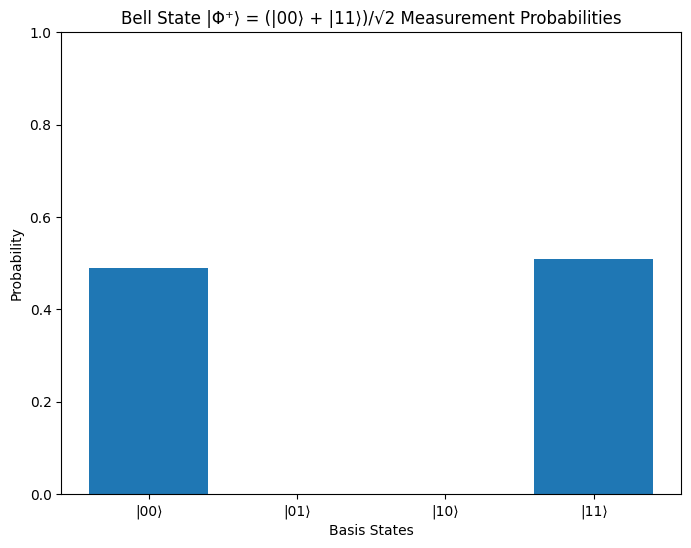

In [7]:
import matplotlib.pyplot as plt

# Calculate probabilities
total_shots = sum(counts.values())
states = ['|00⟩', '|01⟩', '|10⟩', '|11⟩']
probabilities = [counts.get('00', 0)/total_shots, 
                 counts.get('01', 0)/total_shots, 
                 counts.get('10', 0)/total_shots, 
                 counts.get('11', 0)/total_shots]

# Plot the results
plt.figure(figsize=(8, 6))
plt.bar(states, probabilities)
plt.ylim(0, 1)
plt.xlabel('Basis States')
plt.ylabel('Probability')
plt.title('Bell State |Φ⁺⟩ = (|00⟩ + |11⟩)/√2 Measurement Probabilities')
plt.show()

## Exercises: 
- Play around with the Bell state circuit, and make your own circuit. 
- We will cover what the Bell state represents in our entanglement section. 